# Analyse par composantes principales

### Données IRIS 

In [8]:
from sklearn.datasets import load_iris
import numpy as np

iris = load_iris()
X = iris.data
y = iris.target
#print(X.shape)
#print(y.shape)

print(iris)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

Normalisation des données

In [9]:
from sklearn.preprocessing import scale
Xscaled = scale(X)
print(Xscaled)

[[-9.00681170e-01  1.01900435e+00 -1.34022653e+00 -1.31544430e+00]
 [-1.14301691e+00 -1.31979479e-01 -1.34022653e+00 -1.31544430e+00]
 [-1.38535265e+00  3.28414053e-01 -1.39706395e+00 -1.31544430e+00]
 [-1.50652052e+00  9.82172869e-02 -1.28338910e+00 -1.31544430e+00]
 [-1.02184904e+00  1.24920112e+00 -1.34022653e+00 -1.31544430e+00]
 [-5.37177559e-01  1.93979142e+00 -1.16971425e+00 -1.05217993e+00]
 [-1.50652052e+00  7.88807586e-01 -1.34022653e+00 -1.18381211e+00]
 [-1.02184904e+00  7.88807586e-01 -1.28338910e+00 -1.31544430e+00]
 [-1.74885626e+00 -3.62176246e-01 -1.34022653e+00 -1.31544430e+00]
 [-1.14301691e+00  9.82172869e-02 -1.28338910e+00 -1.44707648e+00]
 [-5.37177559e-01  1.47939788e+00 -1.28338910e+00 -1.31544430e+00]
 [-1.26418478e+00  7.88807586e-01 -1.22655167e+00 -1.31544430e+00]
 [-1.26418478e+00 -1.31979479e-01 -1.34022653e+00 -1.44707648e+00]
 [-1.87002413e+00 -1.31979479e-01 -1.51073881e+00 -1.44707648e+00]
 [-5.25060772e-02  2.16998818e+00 -1.45390138e+00 -1.31544430e

Importez la fonction `PCA` donnée par  `sklearn.decomposition`.

Regarder la documentation https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html 
et faites une analyse en composantes principales sur vos données normalisées en utilisant deux composantes. 
Stockez les deux composantes principales dans une variable `pc`.

In [29]:
from sklearn.decomposition import PCA

# n = min(Xscaled.shape[0], Xscaled.shape[1])


pca = PCA(n_components=2)
pc = pca.fit_transform(Xscaled)

print(pca.components_)


[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]


Trouver la fraction de la variance dans les données expliquée par ces 2 composantes principales. 

In [30]:
np.sum(pca.explained_variance_ratio_)

np.float64(0.9581320720000166)

Traçons la nouvelle disposition des données par rapport aux deux composantes principales

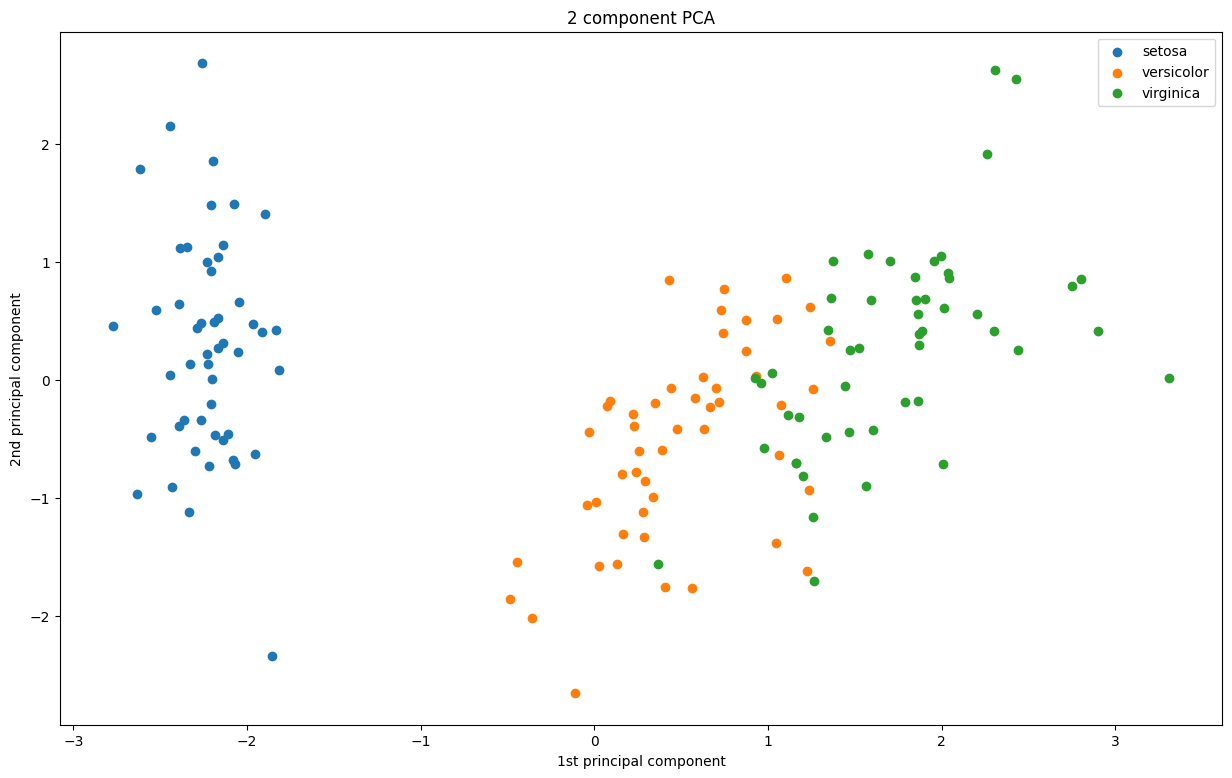

In [31]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (15,9)

for i in range(3): # i=0,1,2 (types des fleurs)
    idx = (y == i)
   
    plt.scatter(pc[idx,0], pc[idx,1], label=iris.target_names[i])
    
   
plt.title('2 component PCA')
plt.xlabel('1st principal component')
plt.ylabel('2nd principal component')
plt.legend()

Nous observons que les données sont assez bien séparées. Mais si nous traçons toutes les variables les unes contre les autres, nous constatons qu'il existe également des paires de variables similaires, voire mieux séparées. 

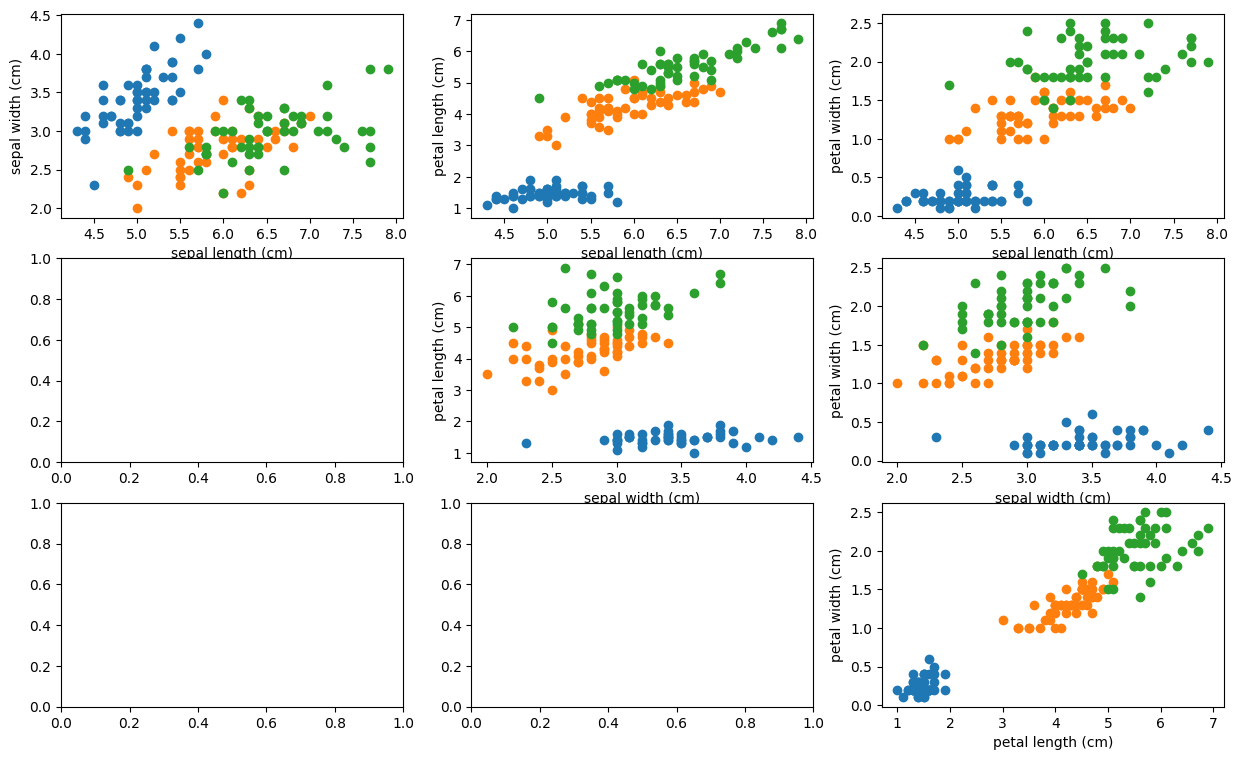

In [28]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (15,9)
fig, ax = plt.subplots(3,3)

for i in range(4):
    for j in range(4):
        if i < j:
            for k in range(3):
                idx = (y == k)
                ax[i][j-1].scatter(X[idx,i], X[idx,j], label=iris.target_names[k])
                ax[i][j-1].set_xlabel(iris.feature_names[i])
                ax[i][j-1].set_ylabel(iris.feature_names[j])

Effectuer une analyse discriminante linéaire en utilisant les 2 composantes principales ci-dessus.
Quelle proportion des * données d'entraînement * est classée correctement?

In [32]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
clf = LDA()
clf.fit(pc, y)
clf.score(pc,y)

0.9333333333333333

Comparez avec les données initiales

In [33]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
clf = LDA()
clf.fit(Xscaled, y)
clf.score(Xscaled,y)

0.98

## Analyse en composantes principales sur un portefeuille 

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
from pandas_datareader import DataReader
import pandas as pd
import yfinance as yf
#from matplotlib.pylab import rcParams
#rcParams['figure.figsize'] = 12, 10
%matplotlib inline

On construit un portefeuille de 10 actifs : IBM, MSFT, FB, T, INTC, ABX, NEM, AU, AEM, GFI. 

In [38]:
tickers = ['IBM','MSFT', 'META', 'T', 'INTC','NEM', 'AU', 'AEM', 'GFI']
portfolio_returns = pd.DataFrame()


start, end = dt.datetime(2015, 9, 1), dt.datetime(2016, 11, 1)
portfolio_returns = yf.download(tickers, start, end).loc[:,'Close'].pct_change()[1:]


print(portfolio_returns)



C:\Users\lione\AppData\Local\Temp\ipykernel_46484\1266330452.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  portfolio_returns = yf.download(tickers, start, end).loc[:,'Close'].pct_change()[1:]
[*********************100%***********************]  9 of 9 completed

Ticker           AEM        AU       GFI       IBM      INTC      META  \
Date                                                                     
2015-09-02 -0.021136  0.000000 -0.050167  0.016611  0.028037  0.030494   
2015-09-03 -0.035140  0.007884  0.007042  0.011927  0.016783 -0.019357   
2015-09-04  0.000877 -0.009127  0.010490 -0.020984 -0.019257  0.001248   
2015-09-08 -0.006576  0.026316 -0.010381  0.024565  0.034362  0.014389   
2015-09-09 -0.048985 -0.037179 -0.016451 -0.014806 -0.008814  0.010164   
...              ...       ...       ...       ...       ...       ...   
2016-10-25  0.026921  0.023686  0.036855  0.002059 -0.004538 -0.007428   
2016-10-26 -0.023997 -0.023138 -0.033176  0.006164 -0.005128 -0.009449   
2016-10-27  0.007645 -0.011103 -0.012255  0.010144 -0.003150 -0.010302   
2016-10-28  0.012918  0.011976  0.004963 -0.004826 -0.002011  0.012337   
2016-10-31  0.028340  0.016272  0.024691  0.007077  0.003742 -0.002285   

Ticker          MSFT       NEM       

In [41]:
from sklearn.decomposition import PCA
num_pc = 2

X = np.asarray(portfolio_returns)

[n,m] = X.shape
print('The number of timestamps is {}.'.format(n))
print('The number of stocks is {}.'.format(m))
print(X)

X=scale(X)
pca = PCA(n_components=num_pc)

pc = pca.fit_transform(X)

percentage_explained_variance_ratio =  pca.explained_variance_ratio_
percentage_sum = np.sum(percentage_explained_variance_ratio)
percentage_cum= np.cumsum(percentage_explained_variance_ratio)


print('{0:.2f}% of the variance is explained by the first 2 PCs'.format(percentage_sum*100))

pca_components = pca.components_


print(pca_components)

The number of timestamps is 294.
The number of stocks is 9.
[[-0.02113588  0.         -0.05016721 ...  0.03682429 -0.03108226
   0.01547057]
 [-0.03513954  0.0078843   0.00704234 ...  0.003229   -0.00123362
   0.0067033 ]
 [ 0.00087741 -0.00912651  0.01048959 ... -0.02045994 -0.03026547
  -0.01452778]
 ...
 [ 0.00764474 -0.01110287 -0.01225476 ... -0.00874158 -0.03841894
   0.00247085]
 [ 0.01291772  0.01197604  0.0049628  ... -0.00382703  0.01695901
  -0.00027405]
 [ 0.02833961  0.01627219  0.02469122 ...  0.0008351   0.0469191
   0.00766911]]
67.13% of the variance is explained by the first 2 PCs
[[ 0.48981997  0.4855935   0.46510703  0.11405771  0.07399805  0.02854275
   0.03996444  0.48823719  0.22063211]
 [-0.10407773 -0.107373   -0.1348654   0.44624456  0.49179232  0.38821907
   0.49730219 -0.0571833   0.3422906 ]]


Notez que la plus grande partie de la variance des rendements de ces actifs peut être expliquée par les deux premières composantes principales.
Nous rassemblons maintenant les deux premières composantes principales et en traçons les contributions.

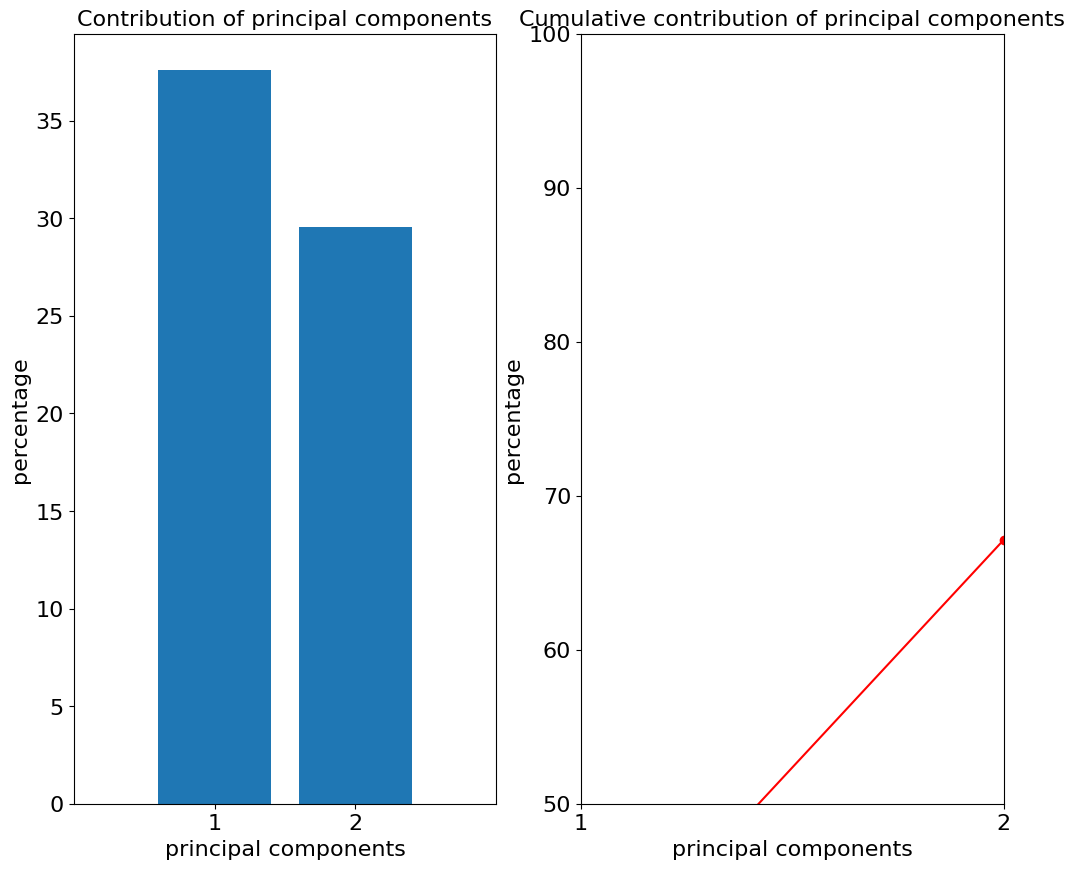

In [ ]:
x = np.arange(1,len(percentage_explained_variance_ratio)+1,1)
plt.figure(figsize=(12,10))
plt.subplot(1, 2, 1)
plt.bar(x, percentage_explained_variance_ratio*100, align = "center")
plt.title('Contribution of principal components',fontsize = 16)
plt.xlabel('principal components',fontsize = 16)
plt.ylabel('percentage',fontsize = 16)
plt.xticks(x,fontsize = 16) 
plt.yticks(fontsize = 16)
plt.xlim([0, num_pc+1])

plt.subplot(1, 2, 2)
plt.plot(x, percentage_cum*100,'ro-')
plt.xlabel('principal components',fontsize = 16)
plt.ylabel('percentage',fontsize = 16)
plt.title('Cumulative contribution of principal components',fontsize = 16)
plt.xticks(x,fontsize = 16) 
plt.yticks(fontsize = 16)
plt.xlim([1, num_pc])
plt.ylim([50,100])

À partir de ces composantes principales, nous pouvons construire des "facteurs de risque statistiques", similaires aux facteurs de risque plus conventionnels. Celles-ci devraient nous donner une idée de la part des rendements du portefeuille provenant de certaines caractéristiques statistiques non observables.

In [45]:
factor_returns = ??? # faire passer les données dans la nouvelle base

print(factor_returns)

[[ 0.41589163 -0.19220526]
 [ 0.60043354  0.01944583]
 [ 0.70142055  0.22025992]
 [-0.03946288 -0.01892128]
 [-0.0562441   0.04181034]
 [-0.07469913  0.04543184]
 [-0.07270401  0.053181  ]
 [ 0.4078595  -0.22102769]
 [ 0.00754018 -0.00915527]]


In [51]:
factor_exposures = pd.DataFrame(index=["factor 1", "factor 2"], 
                                columns=portfolio_returns.columns,
                                data = factor_returns.T).T

factor_exposures

,factor 1,factor 2
AEM,0.415892,-0.192205
AU,0.600434,0.019446
GFI,0.701421,0.220260
IBM,-0.039463,-0.018921
INTC,-0.056244,0.041810
META,-0.074699,0.045432
MSFT,-0.072704,0.053181
NEM,0.407859,-0.221028
T,0.007540,-0.009155


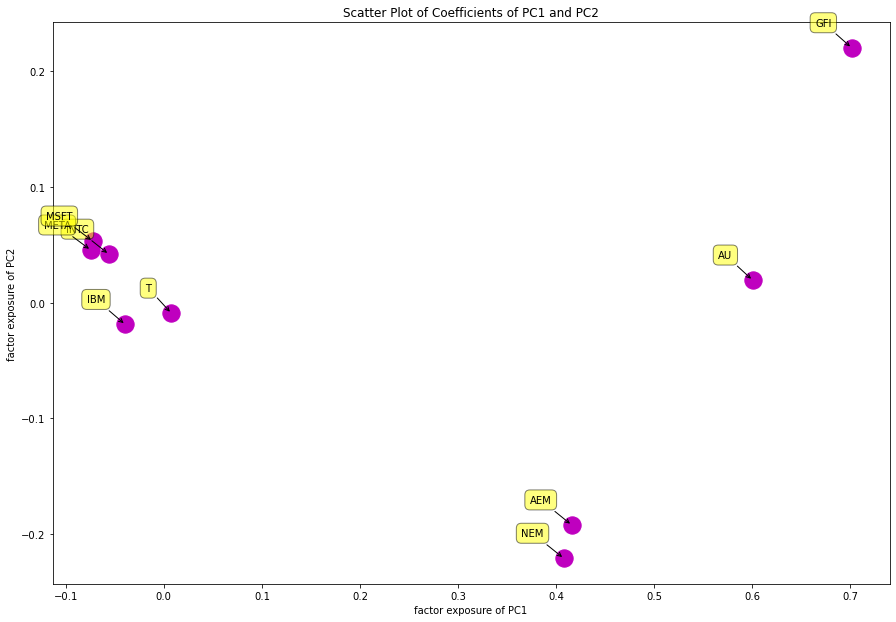

In [54]:
labels = factor_exposures.index
data = factor_exposures.values
plt.figure(figsize=(15,10))
plt.subplots_adjust(bottom = 0.1)
plt.scatter(data[:, 0], data[:, 1], marker='o', s=300, c='m',cmap=plt.get_cmap('Spectral'))
plt.title('Scatter Plot of Coefficients of PC1 and PC2')
plt.xlabel('factor exposure of PC1')
plt.ylabel('factor exposure of PC2')

for label, x, y in zip(labels, data[:, 0], data[:, 1]):
    plt.annotate(
        label,
        xy=(x, y), xytext=(-20, 20),
        textcoords='offset points', ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5),
        arrowprops=dict(arrowstyle = '->', connectionstyle='arc3,rad=0')
    );

La création de facteurs de risque statistiques nous permet de décomposer davantage les rendements d'un portefeuille pour avoir une meilleure idée du risque. Cela peut être utilisé comme une étape supplémentaire après l'attribution de performance avec des facteurs de risque plus courants pour tenter de prendre en compte des risques inconnus supplémentaires.

**Conclusion**: Les deux compsantes principales cachées ont séparé les données en deux groupes. Si on regarde plus en détail on voit que les 5 indices sur la gauche du graphique sont reliés au secteur d'innovation technologique et les 5 autres sont liés à des entreprises de recherche minière d'or. 